In [1]:
import numpy as np

from scripts.functions import (get_reduced_exposures, get_reduced_spectra, coadd_fibers, plot_science_reduction_results, select_bright_fibers)
from scripts.telluric_correction import (query_star_properties, fit_telluric_star_model, fit_telluric_poly_model, apply_telluric_model, plot_star_telluric_model_fit, plot_poly_telluric_model_fit, plot_telluric_correction, windows_from_transmission)
from scripts.flux_calibration import (compute_throughput, save_throughput, plot_throughput_fit, plot_throughput_validation, plot_flux_calibration, load_throughput, plot_throughput, flux_calibrate_exposure, write_fluxcal_fits)

## Load reduced data for post-processing

In [29]:
# GALAXY and TELLURIC STANDARD observations

gal_and_tell_date = '20240725'
gal_and_tell_exposures = get_reduced_exposures(gal_and_tell_date, suffixes=('ssc', 'cf', 'a'))

# print out info for this observation
print('\nEXPOSURES:', end='\n\n')
print('file                           object      exposure time     GA        intermediate products')
for exp_id, exp in gal_and_tell_exposures.items():
    intermediate_data_products = [extension for extension in ('ssc', 'cf', 'a') if extension in exp]

    # save object grating angle
    if (exp['object'] != 'SKY') and (exp['object'] != 'ARC'):
        obj_GA = round(exp['grating_angle'],1)
        
    # print info on observation exposures
    print(f"{exp_id:28s} {exp['object']:15s}  {exp['exptime']:6.1f}        {obj_GA}      {intermediate_data_products}")
print('\nGRATING ANGLE:', obj_GA)

# # save diagnostic plots for the science reduction results
# plot_science_reduction_results(gal_and_tell_date)


EXPOSURES:

file                           object      exposure time     GA        intermediate products
dphN202407250004.4.1         J2114+0032        598.9        37.0      ['ssc', 'cf', 'a']
dphN202407250005.5.1         J2114+0032        598.9        37.0      ['ssc', 'cf', 'a']
dphN202407250006.6.1         J2114+0032        598.9        37.0      ['ssc', 'cf', 'a']
dphN202407250007.7.1         SKY               598.9        37.0      ['cf', 'a']
dphN202407250008.8.1         ARC                 8.7        37.0      ['a']
dphN202407250009.9.1         SKY                 1.5        37.0      []
dphN202407250009.9.2         SKY                 1.5        37.0      []
dphN202407250009.9.3         SKY                 1.5        37.0      []
dphN202407250009.9.4         SKY                 1.5        37.0      []
dphN202407250009.9.5         SKY                 1.5        37.0      []
dphN202407250010.10.1        HIP 103889         29.1        37.0      ['ssc', 'cf', 'a']
dphN20240725001

In [30]:
# SPEC-PHOT STANDARD observations

spec_phot_date = '20241015'
spec_phot_exposures = get_reduced_exposures(spec_phot_date, suffixes=('ssc', 'cf', 'a'))

# print out info for this observation
print('\nEXPOSURES:', end='\n\n')
print('file                           object      exposure time     GA        intermediate products')
for exp_id, exp in spec_phot_exposures.items():
    intermediate_data_products = [extension for extension in ('ssc', 'cf', 'a') if extension in exp]
    spec_phot_GA = round(exp['grating_angle'],1)

    # print info on observation exposures
    print(f"{exp_id:28s} {exp['object']:15s}  {exp['exptime']:6.1f}        {spec_phot_GA}      {intermediate_data_products}")
    
    # find the exposure with the same grating angle as object
    if (obj_GA == spec_phot_GA) and (exp['object'] != 'ARC') and (exp['object'] != 'SKY'):
        spec_phot_filename = exp_id
print(f'\nobservation with GA {obj_GA}:', spec_phot_filename)

# # save diagnostic plots for the science reduction results
# plot_science_reduction_results(spec_phot_date)


EXPOSURES:

file                           object      exposure time     GA        intermediate products
dphN202410150005.5.1         HD 19305           58.9        37.0      ['ssc', 'cf', 'a']
dphN202410150006.6.1         SKY                58.9        37.0      ['cf', 'a']
dphN202410150007.7.1         HD 19305           58.9        50.0      ['ssc', 'cf', 'a']
dphN202410150008.8.1         SKY                58.9        50.0      ['cf', 'a']
dphN202410150009.9.1         HD 19305           58.9        37.0      ['ssc', 'cf', 'a']
dphN202410150010.10.1        SKY                58.9        37.0      ['cf', 'a']
dphN202410150011.11.1        SKY                58.9        29.5      ['cf', 'a']
dphN202410150012.12.1        HD 19305           58.9        29.5      ['ssc', 'cf', 'a']
dphN202410150013.13.1        SKY                58.9        29.5      ['cf', 'a']
dphN202410150014.14.1        HD 19305           58.9        25.0      ['ssc', 'cf', 'a']
dphN202410150015.15.1        SKY       

In [31]:
# use above output to assign these variables
galaxy_name = 'J2114+0032'
telluric_standard_name = 'HIP 103889' #'HIP 105164' # 
spec_phot_standard_name = 'HD 19305'

In [32]:
# identify galaxy, telluric standard, and spec-phot observation dictionaries
for exp_id, exp in gal_and_tell_exposures.items():
    if exp['object'] == telluric_standard_name:
        telluric_standard = exp
    elif exp['object'] == galaxy_name:   # NOTE: if dithered observation, this will save the last dither exposure. To reduce the rest, change this...
        galaxy = exp
for exp_id, exp in spec_phot_exposures.items():
    if exp_id == spec_phot_filename:
        spec_phot = exp

# save their spectra
gal_wave, gal_flux_all, gal_sigma_all, gal_gpcnt_wave, gal_gpcnt_data = get_reduced_spectra(galaxy, gal_and_tell_exposures)
tell_std_wave, tell_std_flux_all, tell_std_sigma_all, _ , _ = get_reduced_spectra(telluric_standard, gal_and_tell_exposures)  # gpcnt same as galaxy since same night of observation
spec_phot_wave, spec_phot_flux_all, spec_phot_sigma_all, spec_phot_gpcnt_wave, spec_phot_gpcnt_data  = get_reduced_spectra(spec_phot, spec_phot_exposures)

# Telluric correction

#### Fit telluric-standard observation with Pypeit stellar + telluric model

In [33]:
# star properties from SIMBAD
star_props = query_star_properties(telluric_standard_name)
print('stellar type:',star_props['sp_type'])
print('V mag:', round(star_props['v_mag'],2))

stellar type: B8III
V mag: 6.49


In [34]:
# select bright star fibers
star_fibers = select_bright_fibers(tell_std_flux_all, frac=0.2)
print('# of bright fibers:', len(star_fibers))

# co-add bright star fibers
telluric_flux, telluric_sigma = coadd_fibers(tell_std_flux_all, tell_std_sigma_all, star_fibers)

star_gpm = np.isfinite(telluric_flux) & np.isfinite(telluric_sigma) & (telluric_sigma > 0)
star_ivar = np.zeros_like(telluric_flux)
star_ivar[star_gpm] = 1.0 / telluric_sigma[star_gpm]**2
star_gpm &= np.isfinite(star_ivar) & (star_ivar < 1e40)   # drop inf ivar

 [WARNING] - 1750194499.py:<module>:11 - RuntimeWarning: overflow encountered in cast


# of bright fibers: 2


In [35]:
telluric_fit = fit_telluric_star_model(telluric_flux, tell_std_wave, star_ivar, star_gpm, star_props, 
                              telluric_standard['airmass'], telluric_standard['exptime'], polyorder=8)

tell_windows = windows_from_transmission(telluric_fit['transmission'], telluric_fit['wave'], threshold=0.98)
print('telluric windows from fit:', tell_windows)

    [INFO] - pypeitdata.py:get_file_path:300 - kurucz93/kp00/kp00_12000.fits.gz does not exist in the expected package directory (/opt/anaconda3/envs/pypeit/lib/python3.13/site-packages/pypeit/data/standards).  Checking cache or downloading the file now.
    [INFO] - flux_calib.py:get_mask:495 -  Masking bad pixels
    [INFO] - flux_calib.py:get_mask:500 -  Masking edges
    [INFO] - flux_calib.py:get_mask:503 -  Masking Below the atmospheric cutoff
    [INFO] - flux_calib.py:mask_stellar_hydrogen:585 - Masking hydrogen recombination lines
    [INFO] - flux_calib.py:mask_stellar_hydrogen:588 -  Masking Balmer
    [INFO] - flux_calib.py:mask_stellar_hydrogen:599 -  Masking Paschen
    [INFO] - flux_calib.py:mask_stellar_hydrogen:610 -  Masking Brackett
    [INFO] - flux_calib.py:mask_stellar_hydrogen:619 -  Masking Pfund
    [INFO] - telluric.py:__init__:2453 - Reading in the pca-based telluric model: TellPCA_3000_26000_R10000.fits
    [INFO] - pypeitdata.py:get_file_path:300 - TellPCA_

differential_evolution step 1: f(x)= 112636.50008536392
differential_evolution step 2: f(x)= 112636.50008536392
differential_evolution step 3: f(x)= 110197.26299477756
differential_evolution step 4: f(x)= 74582.14090083324
differential_evolution step 5: f(x)= 74582.14090083324
differential_evolution step 6: f(x)= 74582.14090083324
differential_evolution step 7: f(x)= 74582.14090083324
differential_evolution step 8: f(x)= 74582.14090083324
differential_evolution step 9: f(x)= 74582.14090083324
differential_evolution step 10: f(x)= 74582.14090083324
differential_evolution step 11: f(x)= 74582.14090083324
differential_evolution step 12: f(x)= 74582.14090083324
differential_evolution step 13: f(x)= 74582.14090083324
differential_evolution step 14: f(x)= 74582.14090083324
differential_evolution step 15: f(x)= 74582.14090083324
differential_evolution step 16: f(x)= 74582.14090083324
differential_evolution step 17: f(x)= 73637.42687170269
differential_evolution step 18: f(x)= 73637.4268717026

 [WARNING] - coadd.py:renormalize_errors:120 - Error renormalization found correction factor sigma_corr = 0.2984136987728591 < 1.
Errors are overestimated so not applying correction.


differential_evolution step 1: f(x)= 176.85076206664564
differential_evolution step 2: f(x)= 176.85076206664564
differential_evolution step 3: f(x)= 176.85076206664564
differential_evolution step 4: f(x)= 176.85076206664564
differential_evolution step 5: f(x)= 176.85076206664564
differential_evolution step 6: f(x)= 176.85076206664564
differential_evolution step 7: f(x)= 176.85076206664564
differential_evolution step 8: f(x)= 169.67838822571355
differential_evolution step 9: f(x)= 169.67838822571355
differential_evolution step 10: f(x)= 169.67838822571355
differential_evolution step 11: f(x)= 168.2447268085103
differential_evolution step 12: f(x)= 166.51233590900668
differential_evolution step 13: f(x)= 166.51233590900668
differential_evolution step 14: f(x)= 164.7602695207753
differential_evolution step 15: f(x)= 164.7602695207753
differential_evolution step 16: f(x)= 164.7602695207753
differential_evolution step 17: f(x)= 163.0633101449533
differential_evolution step 18: f(x)= 163.063

 [WARNING] - coadd.py:renormalize_errors:120 - Error renormalization found correction factor sigma_corr = 0.2891283107684372 < 1.
Errors are overestimated so not applying correction.


  SUCCESS=True  CHI2=160.9  R=4582  shift=-0.54  stretch=1.0003
telluric windows from fit: [(11906.99545294, 11913.88283974), (11932.4787841, 11937.98869354), (11949.6972511, 11960.0283313), (11984.1341851, 11993.77652662), (12000.66391342, 12020.63733514), (12030.27967666, 12053.69679178), (12063.3391333, 12076.425168220001), (12079.18012294, 12086.06750974), (12110.86210222, 12126.70309186), (12137.72291074, 12155.63011642), (12187.312095700001, 12195.57695986), (12213.48416554, 12219.68281366), (12603.9989971, 12670.80664906), (12672.8728651, 12679.07151322), (12681.82646794, 12712.13096986), (12715.57466326, 12721.77331138), (12724.5282661, 12732.10439158), (12736.23682366, 12753.45529066), (12758.9652001, 12765.16384822), (13002.77869282, 13012.421034340001), (13038.59310418, 13046.16922966), (13063.38769666, 13073.71877686), (13094.38093726, 13111.59940426), (13120.5530071, 13163.25480526), (13166.69849866, 13173.585885460001), (13179.784533580001, 13217.665160980001), (13219.042

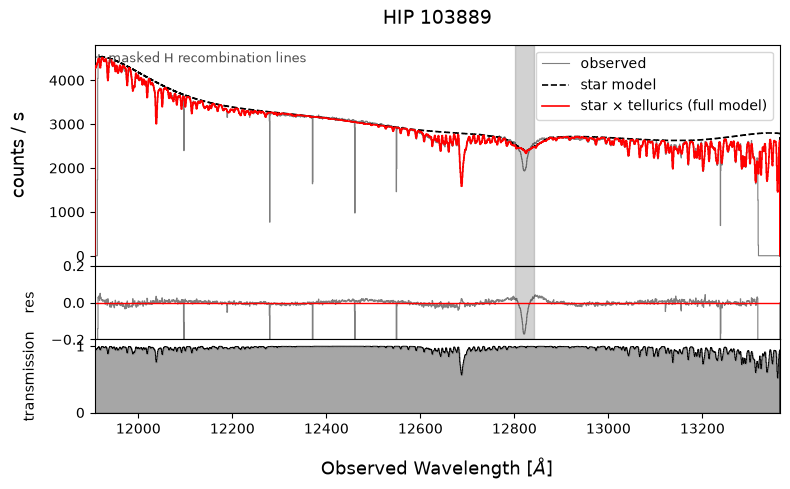

In [36]:
plot_star_telluric_model_fit(tell_std_wave, telluric_flux, telluric_fit, obj_dict=telluric_standard)

#### Apply correction to galaxy observation

In [37]:
# select bright galaxy fibers
gal_fibers = select_bright_fibers(gal_flux_all, frac=0.2)
print('# of bright fibers:', len(gal_fibers))

# of bright fibers: 9


In [38]:
# co-add bright star fibers
gal_coadd, gal_sigma_coadd = coadd_fibers(gal_flux_all, gal_sigma_all, gal_fibers)
gal_gpcnt_arr = np.nansum(gal_gpcnt_data[gal_fibers], axis=0)

In [39]:
gal_flux_tcorr = apply_telluric_model(gal_coadd, gal_sigma_coadd, gal_wave, telluric_fit['transmission'], telluric_fit['wave'])

 [WARNING] - telluric_correction.py:plot_telluric_correction:433 - RuntimeWarning: invalid value encountered in divide
    [INFO] - pypeitdata.py:get_file_path:300 - TellPCA_3000_26000_R10000.fits does not exist in the expected package directory (/opt/anaconda3/envs/pypeit/lib/python3.13/site-packages/pypeit/data/telluric/atm_grids).  Checking cache or downloading the file now.
 [WARNING] - cache.py:fetch_remote_file:242 - Note: If this file takes a while to download, you may wish to used one of the install scripts (e.g., pypeit_install_telluric) to install the file independent of this processing script.


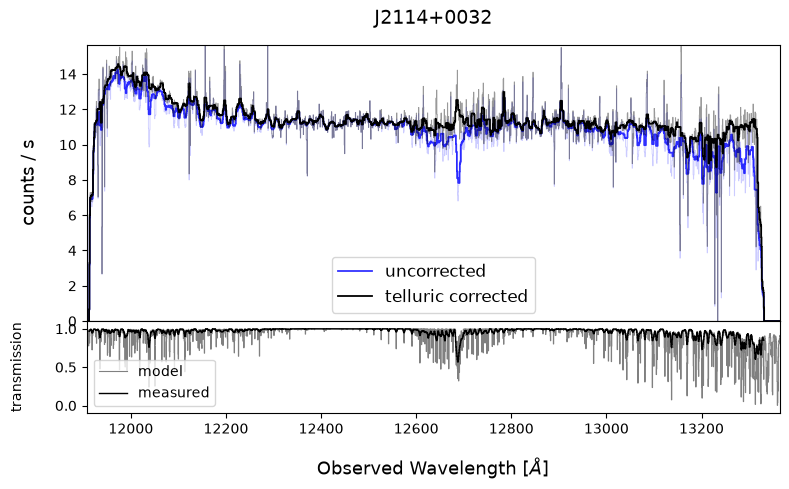

In [40]:
plot_telluric_correction(gal_wave, gal_coadd, gal_flux_tcorr['flux'], obj_dict=galaxy)

#### Fit spectro-photometric standard observation with Pypeit poly + telluric model

In [41]:
# select bright star fibers
spec_phot_star_fibers = select_bright_fibers(spec_phot_flux_all, frac=0.2)
print('# of bright fibers:', len(spec_phot_star_fibers))

# co-add bright star fibers
spec_phot_flux, spec_phot_sigma = coadd_fibers(spec_phot_flux_all, spec_phot_sigma_all, spec_phot_star_fibers)

star_gpm = np.isfinite(spec_phot_flux) & np.isfinite(spec_phot_sigma) & (spec_phot_sigma > 0)
star_ivar = np.zeros_like(spec_phot_flux)
star_ivar[star_gpm] = 1.0 / spec_phot_sigma[star_gpm]**2
star_gpm &= np.isfinite(star_ivar) & (star_ivar < 1e40)   # drop inf ivar

 [WARNING] - 1364398813.py:<module>:11 - RuntimeWarning: overflow encountered in cast


# of bright fibers: 5


In [42]:
spec_phot_fit = fit_telluric_poly_model(spec_phot_flux, spec_phot_wave, star_ivar, star_gpm, 
                                        spec_phot['airmass'], spec_phot['exptime'], polyorder=3)  # 20240701: polyorder=3, 20240725: polyorder=12

tell_windows = windows_from_transmission(spec_phot_fit['transmission'], spec_phot_fit['wave'], threshold=0.98)
print('telluric windows from fit:', tell_windows)

    [INFO] - flux_calib.py:get_mask:495 -  Masking bad pixels
    [INFO] - flux_calib.py:get_mask:500 -  Masking edges
    [INFO] - flux_calib.py:get_mask:503 -  Masking Below the atmospheric cutoff
    [INFO] - flux_calib.py:mask_stellar_hydrogen:585 - Masking hydrogen recombination lines
    [INFO] - flux_calib.py:mask_stellar_hydrogen:588 -  Masking Balmer
    [INFO] - flux_calib.py:mask_stellar_hydrogen:599 -  Masking Paschen
    [INFO] - flux_calib.py:mask_stellar_hydrogen:610 -  Masking Brackett
    [INFO] - flux_calib.py:mask_stellar_hydrogen:619 -  Masking Pfund
    [INFO] - telluric.py:__init__:2453 - Reading in the pca-based telluric model: TellPCA_3000_26000_R10000.fits
    [INFO] - pypeitdata.py:get_file_path:300 - TellPCA_3000_26000_R10000.fits does not exist in the expected package directory (/opt/anaconda3/envs/pypeit/lib/python3.13/site-packages/pypeit/data/telluric/atm_grids).  Checking cache or downloading the file now.
 [WARNING] - cache.py:fetch_remote_file:242 - No

differential_evolution step 1: f(x)= 112777.146106985
differential_evolution step 2: f(x)= 69087.44123365417
differential_evolution step 3: f(x)= 69087.44123365417
differential_evolution step 4: f(x)= 69087.44123365417
differential_evolution step 5: f(x)= 69087.44123365417
differential_evolution step 6: f(x)= 69087.44123365417
differential_evolution step 7: f(x)= 69087.44123365417
differential_evolution step 8: f(x)= 69087.44123365417
differential_evolution step 9: f(x)= 69087.44123365417
differential_evolution step 10: f(x)= 69087.44123365417
differential_evolution step 11: f(x)= 64642.486939914095
differential_evolution step 12: f(x)= 56435.980929067235
differential_evolution step 13: f(x)= 15855.072493019685
differential_evolution step 14: f(x)= 15855.072493019685
differential_evolution step 15: f(x)= 15855.072493019685
differential_evolution step 16: f(x)= 15855.072493019685
differential_evolution step 17: f(x)= 15855.072493019685
differential_evolution step 18: f(x)= 15855.0724930

 [WARNING] - coadd.py:renormalize_errors:120 - Error renormalization found correction factor sigma_corr = 0.9397277359183163 < 1.
Errors are overestimated so not applying correction.


differential_evolution step 1: f(x)= 1131.8256416799077
differential_evolution step 2: f(x)= 1118.804700412004
differential_evolution step 3: f(x)= 1118.804700412004
differential_evolution step 4: f(x)= 1118.804700412004
differential_evolution step 5: f(x)= 1118.804700412004
differential_evolution step 6: f(x)= 1118.804700412004
differential_evolution step 7: f(x)= 1118.804700412004
differential_evolution step 8: f(x)= 1116.7105831422948


 [WARNING] - coadd.py:renormalize_errors:120 - Error renormalization found correction factor sigma_corr = 0.8491242289523381 < 1.
Errors are overestimated so not applying correction.


differential_evolution step 9: f(x)= 1114.8190083610384
differential_evolution step 10: f(x)= 1113.9194054458094
differential_evolution step 11: f(x)= 1111.4309038665906
Polishing solution with 'L-BFGS-B'
differential_evolution step 1: f(x)= 1122.2064356085784
differential_evolution step 2: f(x)= 1108.9822319357345
differential_evolution step 3: f(x)= 1108.9822319357345
differential_evolution step 4: f(x)= 1106.3911577067447
differential_evolution step 5: f(x)= 1106.3911577067447
differential_evolution step 6: f(x)= 1106.3911577067447
differential_evolution step 7: f(x)= 1106.043261512424
differential_evolution step 8: f(x)= 1105.5236034534591
differential_evolution step 9: f(x)= 1104.0713418808982
differential_evolution step 10: f(x)= 1103.9951441434412
Polishing solution with 'L-BFGS-B'


 [WARNING] - coadd.py:renormalize_errors:120 - Error renormalization found correction factor sigma_corr = 0.8474130791797989 < 1.
Errors are overestimated so not applying correction.
 [WARNING] - fitting.py:robust_optimize:626 - Maximum number of iterations maxiter=3 reached in robust_optimize


  SUCCESS=True  CHI2=1101.8  R=4067  shift=1.00  stretch=0.9996
telluric windows from fit: [(11907.239480170001, 11921.703176410001), (11923.76941873, 11938.921862410001), (11940.98810473, 11978.869213930002), (11980.935456250001, 12021.571555210001), (12023.637797530002, 12056.008927210001), (12058.763916970001, 12102.155005690001), (12109.042480090002, 12132.459893050001), (12135.90363025, 12156.56605345), (12161.387285530001, 12171.02974969), (12177.228476650002, 12206.155869130002), (12211.665848650002, 12220.619565370002), (12223.374555130002, 12246.10322065), (12249.546957850001, 12255.745684810001), (12265.388148970002, 12276.40810801), (12325.997923690002, 12334.951640410001), (12602.185647130002, 12671.06039113), (12672.43788601, 12722.716449130001), (12724.093944010001, 12732.358913290002), (12735.80265049, 12753.021336490001), (12758.531316010001, 12765.418790410002), (12768.862527610001, 12775.06125457), (12792.27994057, 12799.85616241), (12803.299899610001, 12809.49862657)

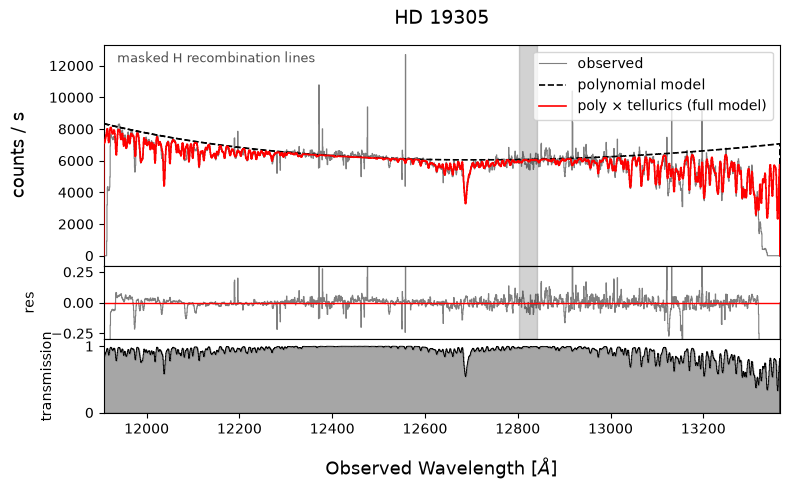

In [43]:
plot_poly_telluric_model_fit(spec_phot_wave, spec_phot_flux, spec_phot_fit, obj_dict=spec_phot)

#### Apply correction to spec-phot observation

In [44]:
# select bright galaxy fibers
spec_phot_fibers = select_bright_fibers(spec_phot_flux_all, frac=0.2)
print('# of bright fibers:', len(spec_phot_fibers))

# of bright fibers: 5


In [45]:
# co-add bright star fibers
spec_phot_coadd, spec_phot_sigma_coadd = coadd_fibers(spec_phot_flux_all, spec_phot_sigma_all, spec_phot_fibers)
spec_phot_gpcnt_arr = np.nansum(spec_phot_gpcnt_data[spec_phot_fibers], axis=0)

In [46]:
spec_phot_flux_tcorr = apply_telluric_model(spec_phot_coadd, spec_phot_sigma_coadd, spec_phot_wave, spec_phot_fit['transmission'], spec_phot_fit['wave'])

 [WARNING] - telluric_correction.py:plot_telluric_correction:433 - RuntimeWarning: invalid value encountered in divide
    [INFO] - pypeitdata.py:get_file_path:300 - TellPCA_3000_26000_R10000.fits does not exist in the expected package directory (/opt/anaconda3/envs/pypeit/lib/python3.13/site-packages/pypeit/data/telluric/atm_grids).  Checking cache or downloading the file now.


 [WARNING] - cache.py:fetch_remote_file:242 - Note: If this file takes a while to download, you may wish to used one of the install scripts (e.g., pypeit_install_telluric) to install the file independent of this processing script.


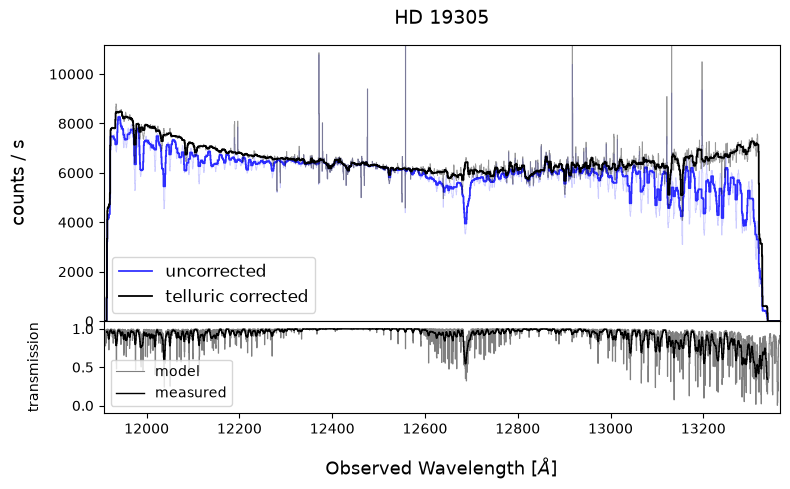

In [47]:
plot_telluric_correction(spec_phot_wave, spec_phot_coadd, spec_phot_flux_tcorr['flux'], obj_dict=spec_phot)

In [48]:
# update flux in dictionary with telluric-corrected flux !
res = apply_telluric_model(np.asarray(spec_phot['flux'], dtype=float), np.asarray(spec_phot_sigma_all, dtype=float), spec_phot_wave, spec_phot_fit['transmission'], spec_phot_fit['wave'])
spec_phot['flux'][:] = res['flux'].astype(spec_phot['flux'].dtype)

# Flux calibration

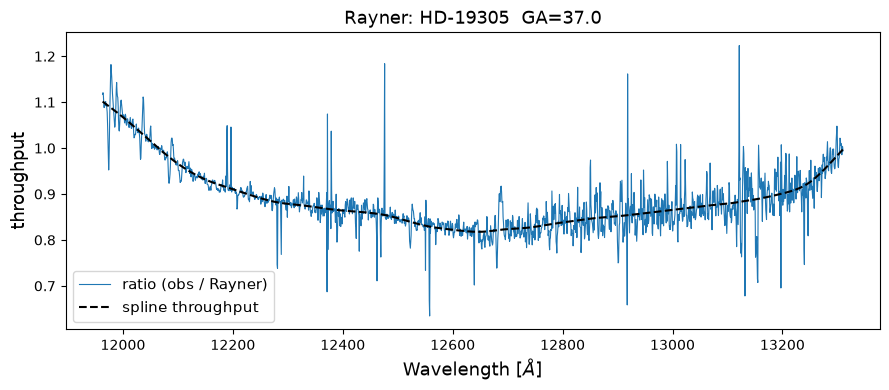

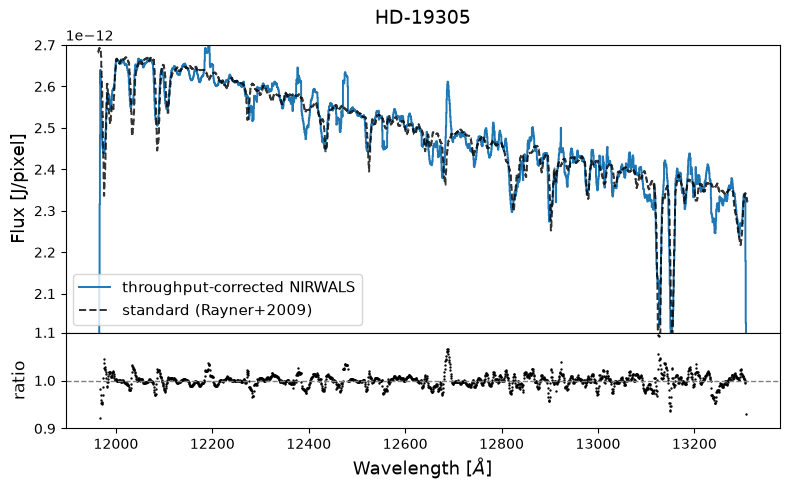

wrote throughput curve: /Users/MarissaPerry/Documents/PhD/projects/packages/NIRWALS_reduction/post_reduction_processing/outputs/throughput_curves/HD-19305_GA37_throughput.csv


In [49]:
# compute the throughput curve from the Rayner standard
throughput_result = compute_throughput(spec_phot_obs=spec_phot, spec_phot_name=spec_phot_standard_name, tell_windows=None) #tell_windows=tell_windows)
plot_throughput_fit(throughput_result, obj_dict=spec_phot)
plot_throughput_validation(throughput_result, obj_dict=spec_phot)
throughput_file = save_throughput(throughput_result)

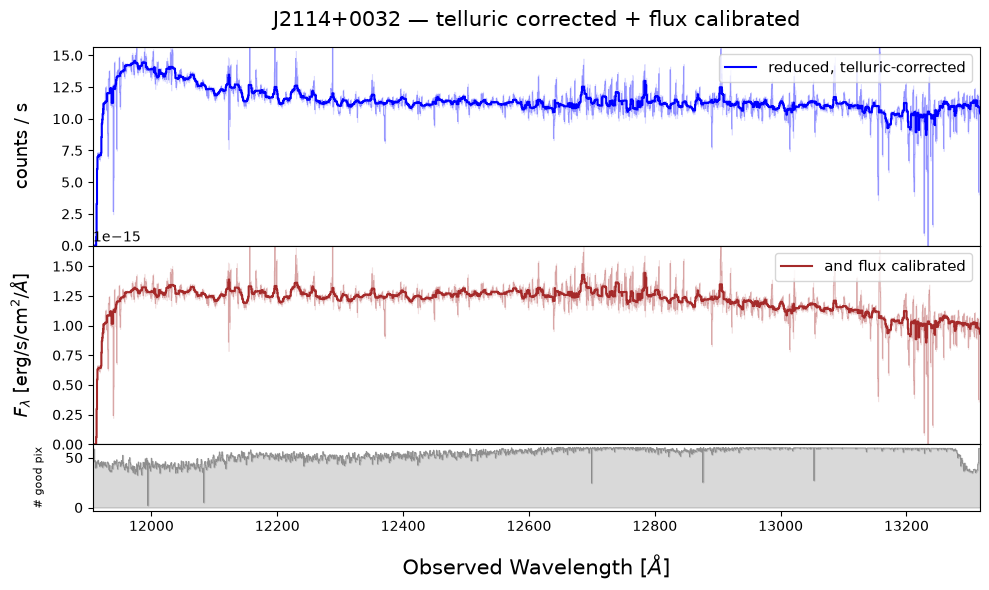

In [50]:
# flux-calibrate the telluric-corrected galaxy
F, F_err = flux_calibrate_exposure(gal_wave, gal_flux_tcorr['flux'], gal_flux_tcorr['sigma'], galaxy, throughput_file)
plot_flux_calibration(gal_wave, gal_flux_tcorr['flux'], gal_flux_tcorr['sigma'], F, F_err, gal_gpcnt_wave, gal_gpcnt_arr, 
                      obj_dict=galaxy, title=f"{galaxy_name} — telluric corrected + flux calibrated")

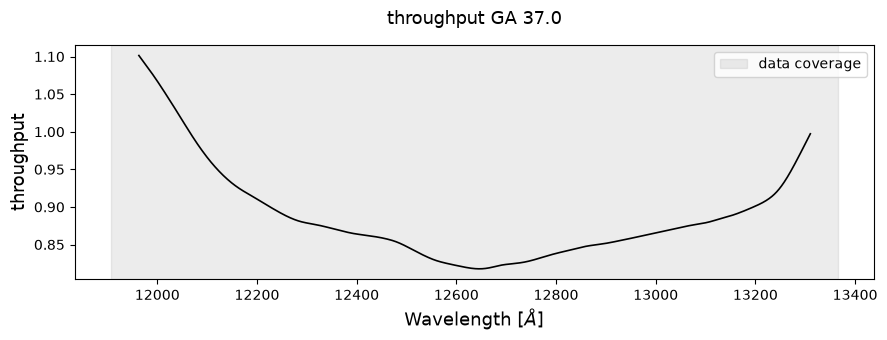

In [51]:
twave, tvalue = load_throughput(throughput_file)
plot_throughput(twave, tvalue, wave_range=(gal_wave.min(), gal_wave.max()), tell_windows=None, title=f"throughput GA {obj_GA}")

In [52]:
ssc_file = galaxy['ssc']['file']
out_file = ssc_file.replace('ssc.fits', 'tellcorr_fluxcal.fits')

write_fluxcal_fits(
    template_file=ssc_file,
    wave=gal_wave, 
    flux=F, sigma=F_err,
    out_file=out_file, 
    throughput_file=throughput_file
)
print('wrote', out_file)

wrote /Users/MarissaPerry/Documents/PhD/projects/packages/NIRWALS_reduction/nirwals_pipeline/20240725/2024-1-LSP-001/product/dphN202407250006.6.1.reduced.tellcorr_fluxcal.fits
